## Part 1: Setup & Configuration

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
from LSTM_Price_Predictor import LSTMPricePredictor
from Data_Handling import get_data_auto

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Libraries imported successfully")
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d')}")

✓ Libraries imported successfully
📅 Analysis Date: 2026-01-20


### 1.2 Model Configuration

In [2]:
# Data parameters
SYMBOL = "SPY"
TIMEFRAME_UNIT = "Day"
MULTIPLIER = 1  # Daily bars

# Time periods
TRAIN_START = "2022-01-01"
TRAIN_END = "2024-09-30"   # 3 years training
TEST_START = "2024-10-01"
TEST_END = "2025-01-31"     # ~4 months testing

# Model architecture (optimized to reduce overfitting)
LOOKBACK_WINDOW = 60        # 60 trading days (~3 months)
PREDICTION_HORIZON = 1      # Train on 1-day only (efficient & accurate)
LSTM_UNITS = 32             # Reduced from 64 to prevent overfitting
NUM_LAYERS = 1              # Reduced from 2 to prevent overfitting
DROPOUT = 0.4               # Increased from 0.2 for better regularization

# Training parameters
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.001

# Testing parameters - Recursive multi-step prediction
TEST_HORIZONS = [1, 2, 3, 5, 6, 7, 8, 9, 10]  # Recursively predict up to 10 days ahead

print("="*80)
print("CONFIGURATION SUMMARY")
print("="*80)
print(f"\n📊 Data:")
print(f"   Symbol: {SYMBOL}")
print(f"   Timeframe: {MULTIPLIER} {TIMEFRAME_UNIT}")
print(f"   Training: {TRAIN_START} → {TRAIN_END}")
print(f"   Testing: {TEST_START} → {TEST_END}")
print(f"\n🏗️  Architecture:")
print(f"   Lookback: {LOOKBACK_WINDOW} days")
print(f"   LSTM: {NUM_LAYERS} layers × {LSTM_UNITS} units")
print(f"   Dropout: {DROPOUT}")
print(f"\n🎯 Training Strategy:")
print(f"   Train: {PREDICTION_HORIZON}-day ahead (single step)")
print(f"   Test: Recursive up to {max(TEST_HORIZONS)} days (predictions feed forward)")
print(f"   Epochs: {EPOCHS} (with early stopping)")
print(f"   Batch Size: {BATCH_SIZE}")
print("="*80)

CONFIGURATION SUMMARY

📊 Data:
   Symbol: SPY
   Timeframe: 1 Day
   Training: 2022-01-01 → 2024-09-30
   Testing: 2024-10-01 → 2025-01-31

🏗️  Architecture:
   Lookback: 60 days
   LSTM: 1 layers × 32 units
   Dropout: 0.4

🎯 Training Strategy:
   Train: 1-day ahead (single step)
   Test: Recursive up to 10 days (predictions feed forward)
   Epochs: 50 (with early stopping)
   Batch Size: 32


## Part 2: Data Loading & Preparation

### 2.1 Load Data

In [3]:
print("Loading training data...")
train_data = get_data_auto(
    symbol=SYMBOL,
    start=TRAIN_START,
    end=TRAIN_END,
    timeframe_unit=TIMEFRAME_UNIT,
    multiplier=MULTIPLIER
)

print("Loading test data...")
test_data = get_data_auto(
    symbol=SYMBOL,
    start=TEST_START,
    end=TEST_END,
    timeframe_unit=TIMEFRAME_UNIT,
    multiplier=MULTIPLIER
)

print("\n" + "="*80)
print("DATA LOADED")
print("="*80)
print(f"\n📈 Training Data:")
print(f"   Samples: {len(train_data):,} days")
print(f"   Period: {train_data.index[0].date()} → {train_data.index[-1].date()}")
print(f"   Duration: {(train_data.index[-1] - train_data.index[0]).days} calendar days")
print(f"\n📊 Test Data:")
print(f"   Samples: {len(test_data):,} days")
print(f"   Period: {test_data.index[0].date()} → {test_data.index[-1].date()}")
print(f"   Duration: {(test_data.index[-1] - test_data.index[0]).days} calendar days")
print(f"\n🔢 Features: {list(train_data.columns)}")
print("="*80)

Loading training data...
Loading test data...

DATA LOADED

📈 Training Data:
   Samples: 688 days
   Period: 2022-01-03 → 2024-09-27
   Duration: 997 calendar days

📊 Test Data:
   Samples: 83 days
   Period: 2024-10-01 → 2025-01-30
   Duration: 121 calendar days

🔢 Features: ['Open', 'High', 'Low', 'Close', 'Volume']
Loading test data...

DATA LOADED

📈 Training Data:
   Samples: 688 days
   Period: 2022-01-03 → 2024-09-27
   Duration: 997 calendar days

📊 Test Data:
   Samples: 83 days
   Period: 2024-10-01 → 2025-01-30
   Duration: 121 calendar days

🔢 Features: ['Open', 'High', 'Low', 'Close', 'Volume']


### 2.2 Data Overview

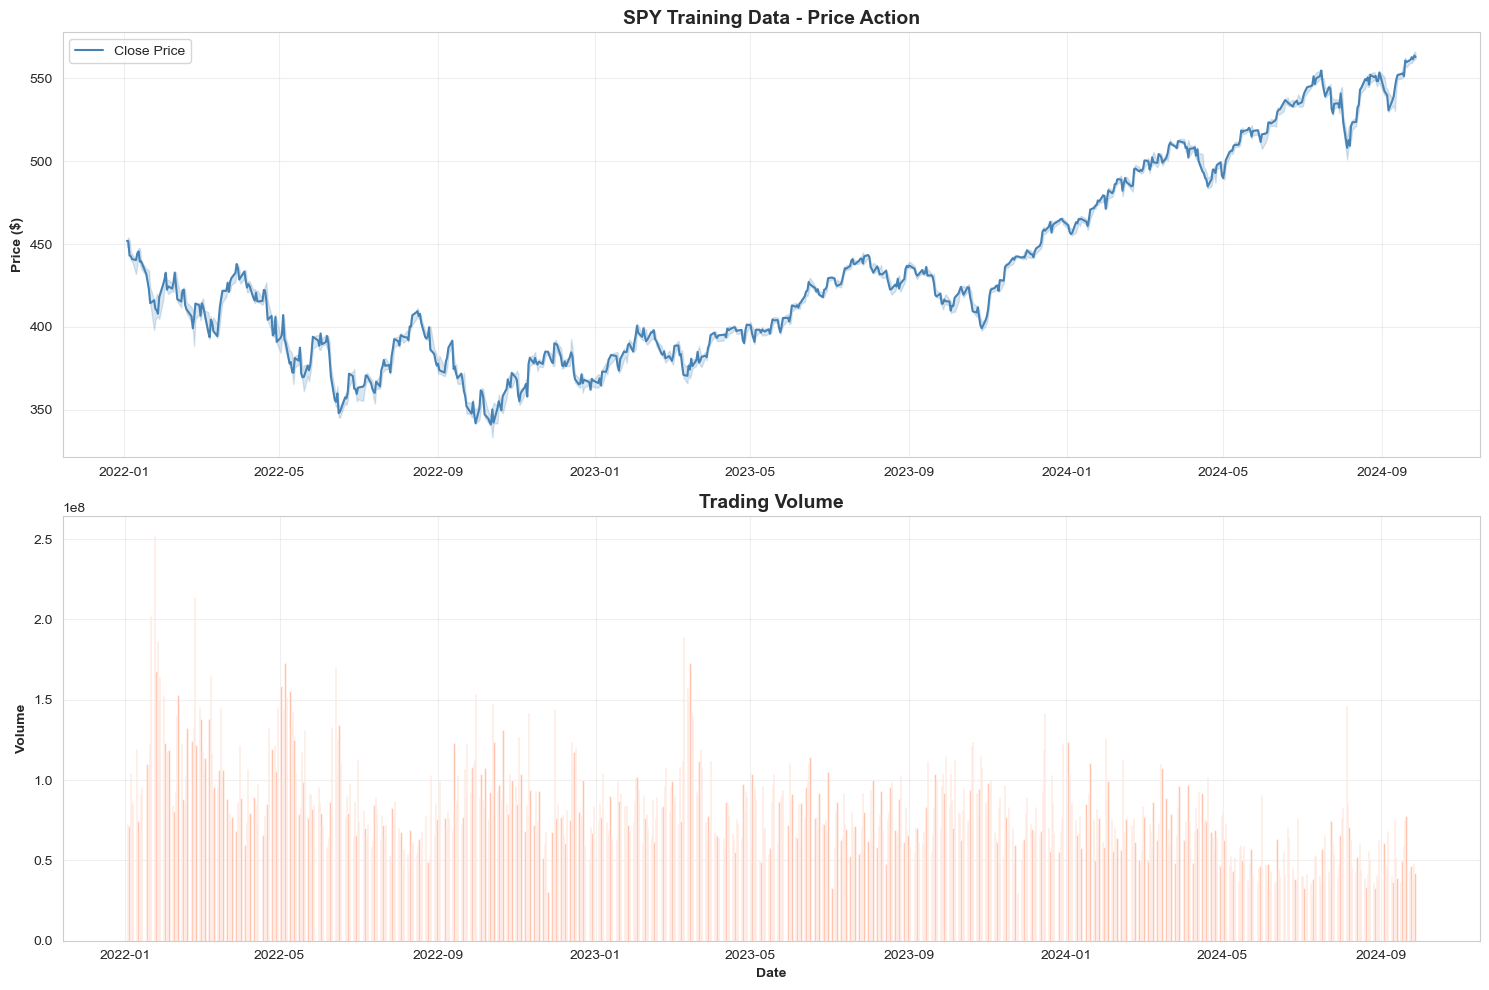


Training Data Statistics:
field        Open        High         Low       Close        Volume
count  688.000000  688.000000  688.000000  688.000000  6.880000e+02
mean   431.848532  434.498976  429.030341  431.931261  8.100900e+07
std     57.422679   57.030153   57.668508   57.372575  2.880642e+07
min    334.149045  344.301478  333.096480  341.182068  2.728970e+07
25%    386.918557  389.386985  384.060064  387.397354  6.255545e+07
50%    419.827430  422.646908  416.803286  419.480850  7.653445e+07
75%    472.484714  474.268113  471.218481  472.130951  9.386328e+07
max    565.808988  566.134081  561.908063  563.760010  2.517839e+08


In [4]:
# Visualize training data
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Price chart
ax1 = axes[0]
ax1.plot(train_data.index, train_data['Close'], linewidth=1.5, color='steelblue', label='Close Price')
ax1.fill_between(train_data.index, train_data['Low'], train_data['High'], alpha=0.2, color='steelblue')
ax1.set_title(f'{SYMBOL} Training Data - Price Action', fontweight='bold', fontsize=14)
ax1.set_ylabel('Price ($)', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Volume chart
ax2 = axes[1]
ax2.bar(train_data.index, train_data['Volume'], color='coral', alpha=0.6, width=1)
ax2.set_title('Trading Volume', fontweight='bold', fontsize=14)
ax2.set_xlabel('Date', fontweight='bold')
ax2.set_ylabel('Volume', fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nTraining Data Statistics:")
print(train_data[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

## Part 3: Model Training

### 3.1 Initialize and Train Model

In [5]:
print("="*80)
print("TRAINING LSTM MODEL")
print("="*80)
print(f"\nStrategy: Train on {PREDICTION_HORIZON}-day predictions")
print(f"Testing: Will evaluate all horizons: {TEST_HORIZONS} days\n")

# Initialize model
model = LSTMPricePredictor(
    lookback_window=LOOKBACK_WINDOW,
    prediction_horizon=PREDICTION_HORIZON,  # Train on all horizons
    lstm_units=LSTM_UNITS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    prediction_mode='recursive',  # Enable recursive predictions
    verbose=1
)

# Train model
print("Training in progress...\n")
history = model.fit(
    train_data,
    validation_split=0.2,
    early_stopping_patience=10
)

print("\n" + "="*80)
print("✓ TRAINING COMPLETE")
print("="*80)

TRAINING LSTM MODEL

Strategy: Train on 1-day predictions
Testing: Will evaluate all horizons: [1, 2, 3, 5, 6, 7, 8, 9, 10] days

Training in progress...

Computing returns from 688 candles...
Creating sequences (lookback=60, horizon=1)...
Generated 628 training sequences
Input shape: (628, 60, 5), Output shape: (628, 1, 5)
Building LSTM model...
Model parameters: 5,029
Training model...
Epoch 1/50
Model parameters: 5,029
Training model...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 1.0373 - mae: 0.7577 - val_loss: 0.7126 - val_mae: 0.6131
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 1.0373 - mae: 0.7577 - val_loss: 0.7126 - val_mae: 0.6131
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.0197 - mae: 0.7532 - val_loss: 0.7004 - val_mae: 0.6079
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.0197 - mae: 0.7532 - val_loss: 0.7004 - val_mae: 0.6079
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.9961 - mae: 0.7423 - val_lo

### 3.2 Training History

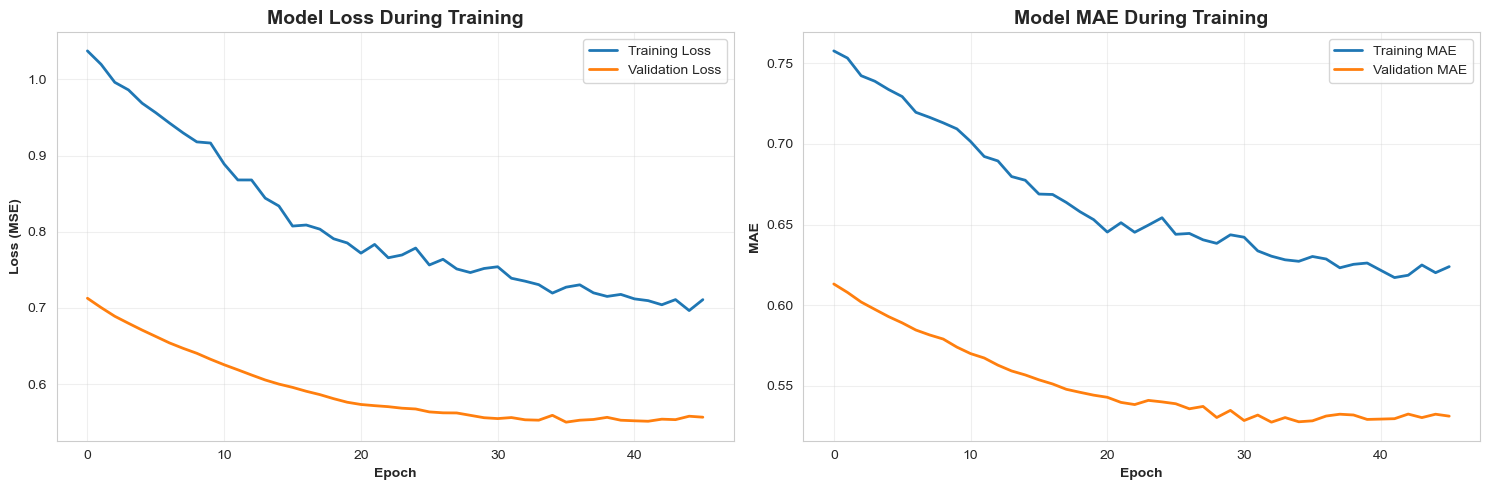


Final Training Metrics:
  Training Loss: 0.710784
  Validation Loss: 0.556449
  Training MAE: 0.623911
  Validation MAE: 0.531206
  Epochs Trained: 46


In [6]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1 = axes[0]
ax1.plot(history.training_history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.training_history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_title('Model Loss During Training', fontweight='bold', fontsize=14)
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Loss (MSE)', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# MAE
ax2 = axes[1]
ax2.plot(history.training_history.history['mae'], label='Training MAE', linewidth=2)
ax2.plot(history.training_history.history['val_mae'], label='Validation MAE', linewidth=2)
ax2.set_title('Model MAE During Training', fontweight='bold', fontsize=14)
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('MAE', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Training Metrics:")
print(f"  Training Loss: {history.training_history.history['loss'][-1]:.6f}")
print(f"  Validation Loss: {history.training_history.history['val_loss'][-1]:.6f}")
print(f"  Training MAE: {history.training_history.history['mae'][-1]:.6f}")
print(f"  Validation MAE: {history.training_history.history['val_mae'][-1]:.6f}")
print(f"  Epochs Trained: {len(history.training_history.history['loss'])}")

## Part 4: Predictions & Evaluation

### 4.1 Generate Recursive Multi-Step Predictions

In [7]:
# Custom recursive prediction function - Updated for OHLCV predictions
def generate_recursive_predictions(model, test_data, horizons):
    """
    Generate recursive multi-step predictions where each prediction feeds into the next.
    Model now predicts full OHLCV (all 5 features) to match input dimensions.
    
    Model is trained on 1-day ahead, but we recursively predict multiple days by:
    1. Predict day 1 OHLCV using real data
    2. Predict day 2 OHLCV using real data + predicted day 1
    3. Predict day 3 OHLCV using real data + predicted days 1 & 2
    ... and so on
    """
    print(f"Generating recursive OHLCV predictions for horizons: {horizons}")
    print(f"This will take the 1-day model and recursively predict {max(horizons)} steps ahead")
    print(f"Each prediction is now complete OHLCV (Open, High, Low, Close, Volume)\n")
    
    # Get the base predictions (1-day ahead) - now includes OHLC
    # We'll only predict for positions where we have enough lookback
    # This avoids the "Not enough data" error
    valid_start = model.lookback_window
    valid_data = test_data.iloc[valid_start:].copy()
    
    print(f"Predicting for {len(valid_data)} valid test samples (skipping first {valid_start} for lookback)")
    
    base_predictions = model.predict(test_data, start_idx=valid_start)
    
    # Extract actual OHLCV and prepare result dataframe
    results = pd.DataFrame(index=base_predictions.index)
    
    # Store actual OHLCV
    results['actual_open'] = base_predictions['actual_open']
    results['actual_high'] = base_predictions['actual_high']
    results['actual_low'] = base_predictions['actual_low']
    results['actual_close'] = base_predictions['actual_close']
    results['actual_volume'] = base_predictions['actual_volume']
    results['actual_price'] = base_predictions['actual_price']  # Backward compatibility
    
    # We already have 1-day OHLCV predictions
    if 'pred_open_1' in base_predictions.columns:
        results['pred_open_1'] = base_predictions['pred_open_1']
        results['pred_high_1'] = base_predictions['pred_high_1']
        results['pred_low_1'] = base_predictions['pred_low_1']
        results['pred_close_1'] = base_predictions['pred_close_1']
        results['pred_volume_1'] = base_predictions['pred_volume_1']
        results['pred_price_1'] = base_predictions['pred_price_1']  # Backward compatibility
    
    # Now generate longer horizon predictions recursively
    max_horizon = max([h for h in horizons if h > 1], default=1)
    
    if max_horizon > 1:
        # We need to do recursive prediction manually for each test sample
        for result_idx, timestamp in enumerate(results.index):
            # Get position in test_data
            test_idx = test_data.index.get_loc(timestamp)
            
            # Get the historical data window (already validated we have enough)
            start_idx = test_idx - model.lookback_window
            end_idx = test_idx
            
            # Prepare initial sequence
            hist_data = test_data.iloc[start_idx:end_idx].copy()
            
            # Store predicted OHLCV for all horizons
            horizon_preds = {
                'open': {},
                'high': {},
                'low': {},
                'close': {},
                'volume': {}
            }
            
            # Recursively predict each step
            for step in range(1, max_horizon + 1):
                if step == 1:
                    # First step: use model's 1-day prediction (already have it)
                    horizon_preds['open'][1] = results['pred_open_1'].iloc[result_idx]
                    horizon_preds['high'][1] = results['pred_high_1'].iloc[result_idx]
                    horizon_preds['low'][1] = results['pred_low_1'].iloc[result_idx]
                    horizon_preds['close'][1] = results['pred_close_1'].iloc[result_idx]
                    horizon_preds['volume'][1] = results['pred_volume_1'].iloc[result_idx]
                else:
                    # Subsequent steps: use previous predicted OHLCV as "new data"
                    prev_open = horizon_preds['open'][step - 1]
                    prev_high = horizon_preds['high'][step - 1]
                    prev_low = horizon_preds['low'][step - 1]
                    prev_close = horizon_preds['close'][step - 1]
                    prev_volume = horizon_preds['volume'][step - 1]
                    
                    # Create a new row with predicted OHLCV
                    new_row = pd.DataFrame({
                        'Open': [prev_open],
                        'High': [prev_high],
                        'Low': [prev_low],
                        'Close': [prev_close],
                        'Volume': [prev_volume]
                    }, index=[hist_data.index[-1] + pd.Timedelta(days=1)])
                    
                    # Slide window forward
                    hist_data = pd.concat([hist_data.iloc[1:], new_row])
                    
                    # Predict next step (returns OHLCV)
                    step_pred = model.predict(hist_data, start_idx=model.lookback_window)
                    
                    # Extract predicted OHLCV for this step
                    horizon_preds['open'][step] = step_pred['pred_open_1'].iloc[-1]
                    horizon_preds['high'][step] = step_pred['pred_high_1'].iloc[-1]
                    horizon_preds['low'][step] = step_pred['pred_low_1'].iloc[-1]
                    horizon_preds['close'][step] = step_pred['pred_close_1'].iloc[-1]
                    horizon_preds['volume'][step] = step_pred['pred_volume_1'].iloc[-1]
            
            # Store predictions for requested horizons
            for h in horizons:
                if h > 1 and h <= max_horizon and h in horizon_preds['close']:
                    # Create columns if they don't exist
                    for price_type in ['open', 'high', 'low', 'close', 'volume']:
                        col_name = f'pred_{price_type}_{h}'
                        if col_name not in results.columns:
                            results[col_name] = np.nan
                        results.loc[timestamp, col_name] = horizon_preds[price_type][h]
                    
                    # Backward compatibility
                    if f'pred_price_{h}' not in results.columns:
                        results[f'pred_price_{h}'] = np.nan
                    results.loc[timestamp, f'pred_price_{h}'] = horizon_preds['close'][h]
    
    return results

print("="*80)
print("GENERATING RECURSIVE MULTI-STEP PREDICTIONS")
print("="*80)
print(f"\nStrategy:")
print(f"  • Model trained on: {PREDICTION_HORIZON}-day ahead")
print(f"  • Recursive prediction: Use each prediction as input for the next")
print(f"  • Test horizons: {TEST_HORIZONS} days\n")

# Generate predictions
predictions = generate_recursive_predictions(model, test_data, TEST_HORIZONS)

print(f"\n✓ Recursive predictions complete!")
print(f"   Generated {len(predictions):,} test samples")
print(f"\nAvailable prediction columns:")
pred_cols = [col for col in predictions.columns if 'pred_price' in col]
print(pred_cols)

# Show sample predictions
print("\nSample predictions (first 10 rows):")
display_cols = ['actual_price'] + pred_cols[:6]  # Show up to 6 horizons
print(predictions[display_cols].head(10).to_string())

GENERATING RECURSIVE MULTI-STEP PREDICTIONS

Strategy:
  • Model trained on: 1-day ahead
  • Recursive prediction: Use each prediction as input for the next
  • Test horizons: [1, 2, 3, 5, 6, 7, 8, 9, 10] days

Generating recursive OHLCV predictions for horizons: [1, 2, 3, 5, 6, 7, 8, 9, 10]
This will take the 1-day model and recursively predict 10 steps ahead
Each prediction is now complete OHLCV (Open, High, Low, Close, Volume)

Predicting for 23 valid test samples (skipping first 60 for lookback)
Generating 23 predictions in batched mode...
Predictions complete!
Predictions complete!


ValueError: Not enough data for predictions. Need at least 61 samples.

### 4.2 Multi-Horizon Performance Analysis

In [ ]:
print("="*80)
print("MULTI-HORIZON PERFORMANCE EVALUATION")
print("="*80)

# Store results for each horizon
horizon_results = []

for horizon in TEST_HORIZONS:
    pred_col = f'pred_price_{horizon}'
    
    if pred_col not in predictions.columns:
        print(f"\n⚠️  Warning: {pred_col} not found in predictions")
        print(f"   Model may need prediction_horizon >= {horizon} or recursive mode enabled")
        continue
    
    # Calculate actual future price
    future_col = f'actual_future_{horizon}'
    predictions[future_col] = predictions['actual_price'].shift(-horizon)
    
    # Filter valid predictions
    valid_mask = predictions[future_col].notna()
    valid_preds = predictions[valid_mask].copy()
    
    # Calculate metrics
    mae = np.abs(valid_preds[pred_col] - valid_preds[future_col]).mean()
    rmse = np.sqrt(((valid_preds[pred_col] - valid_preds[future_col]) ** 2).mean())
    mape = (np.abs(valid_preds[pred_col] - valid_preds[future_col]) / valid_preds[future_col]).mean() * 100
    
    # Directional accuracy
    direction_correct = (
        np.sign(valid_preds[pred_col] - valid_preds['actual_price']) == 
        np.sign(valid_preds[future_col] - valid_preds['actual_price'])
    )
    directional_accuracy = direction_correct.mean() * 100
    
    horizon_results.append({
        'Horizon (days)': horizon,
        'Valid Predictions': len(valid_preds),
        'MAE ($)': mae,
        'RMSE ($)': rmse,
        'MAPE (%)': mape,
        'Directional Accuracy (%)': directional_accuracy
    })

# Display results
horizon_df = pd.DataFrame(horizon_results)
print("\n" + horizon_df.to_string(index=False))

print(f"\n{'='*80}")
print("KEY INSIGHTS:")
print(f"{'='*80}")
best_horizon = horizon_df.loc[horizon_df['Directional Accuracy (%)'].idxmax()]
print(f"\n✓ Best performing horizon: {int(best_horizon['Horizon (days)'])} days")
print(f"  Directional Accuracy: {best_horizon['Directional Accuracy (%)']:.2f}%")
print(f"  MAE: ${best_horizon['MAE ($)']:.2f}")

# Check if accuracy degrades with horizon
if len(horizon_df) > 1:
    acc_trend = horizon_df['Directional Accuracy (%)'].iloc[-1] - horizon_df['Directional Accuracy (%)'].iloc[0]
    if acc_trend < 0:
        print(f"\n📉 Expected pattern: Accuracy degrades from {horizon_df['Directional Accuracy (%)'].iloc[0]:.1f}% to {horizon_df['Directional Accuracy (%)'].iloc[-1]:.1f}%")
        print(f"   (Longer horizons harder to predict)")
    else:
        print(f"\n📈 Interesting: Accuracy improves to {horizon_df['Directional Accuracy (%)'].iloc[-1]:.1f}%")
        print(f"   (Model may be capturing longer-term trends)")

MULTI-HORIZON PERFORMANCE EVALUATION

 Horizon (days)  Valid Predictions     MAE ($)    RMSE ($)   MAPE (%)  Directional Accuracy (%)
              1                 13   51.977605   64.240336   8.908725                 69.230769
              2                 12  120.239754  147.843258  20.692406                 83.333333
              3                 11  170.459065  204.228640  29.308828                 72.727273
              5                  9  266.068348  314.970971  45.788841                 22.222222
              7                  7  430.086552  580.917832  74.479434                 42.857143
             10                  4 1092.623707 1614.269607 187.549867                 50.000000

KEY INSIGHTS:

✓ Best performing horizon: 2 days
  Directional Accuracy: 83.33%
  MAE: $120.24

📉 Expected pattern: Accuracy degrades from 69.2% to 50.0%
   (Longer horizons harder to predict)


### 4.3 Visualize Multi-Horizon Performance

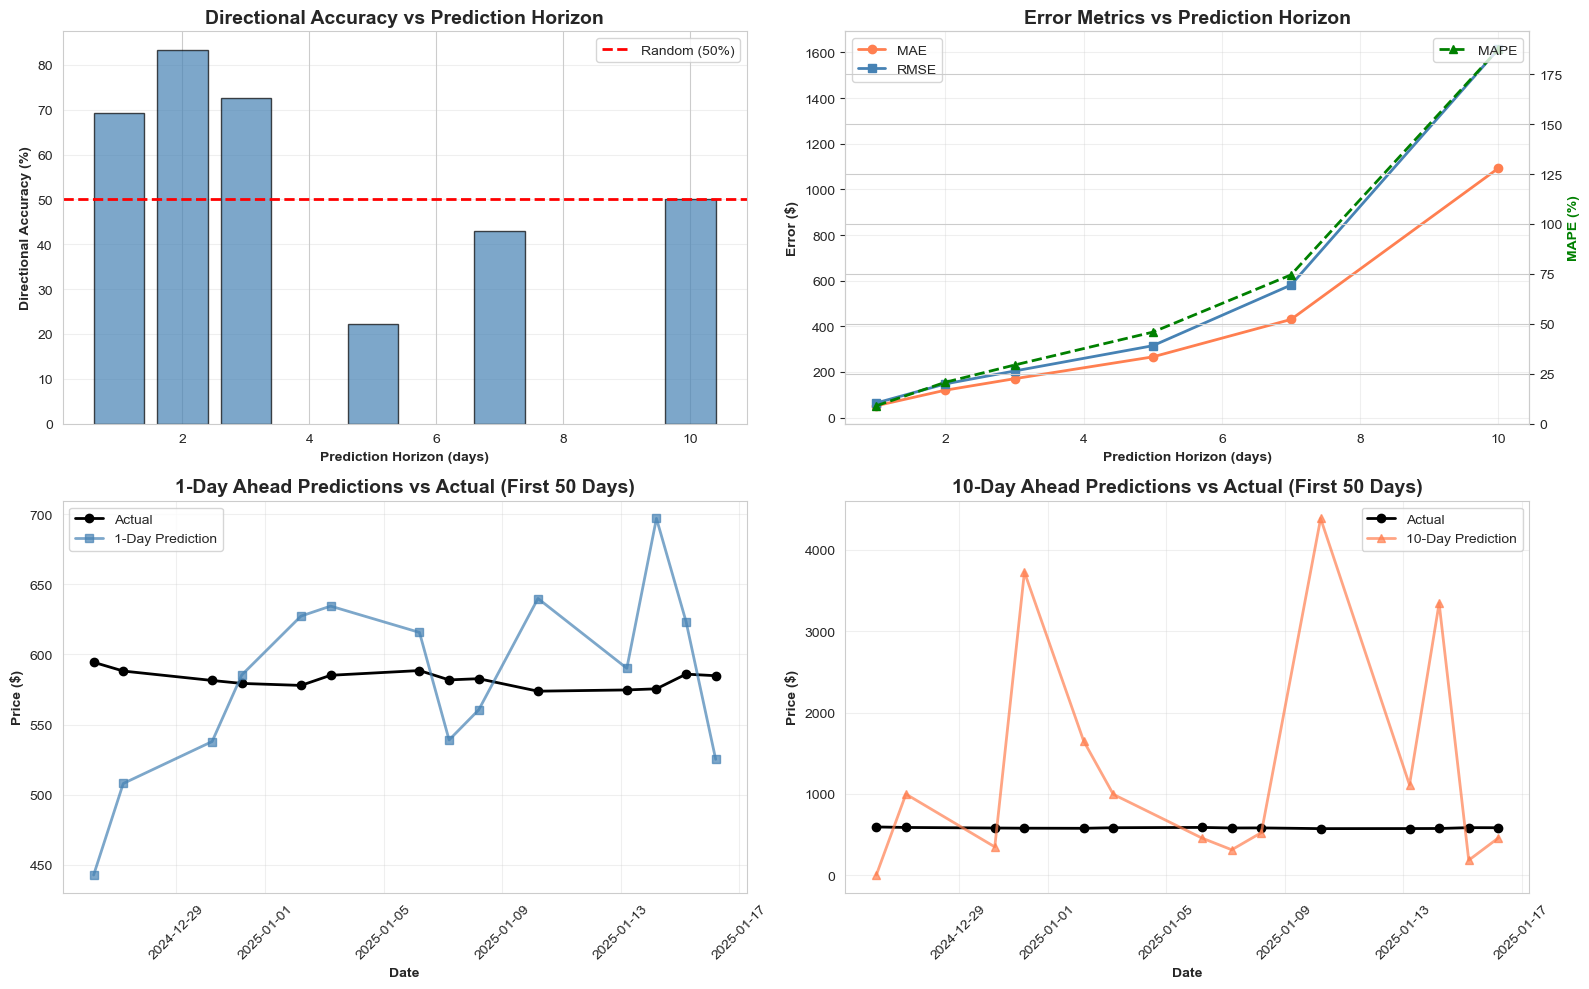

In [ ]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Directional Accuracy by Horizon
ax1 = axes[0, 0]
ax1.bar(horizon_df['Horizon (days)'], horizon_df['Directional Accuracy (%)'], 
        color='steelblue', alpha=0.7, edgecolor='black')
ax1.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Random (50%)')
ax1.set_xlabel('Prediction Horizon (days)', fontweight='bold')
ax1.set_ylabel('Directional Accuracy (%)', fontweight='bold')
ax1.set_title('Directional Accuracy vs Prediction Horizon', fontweight='bold', fontsize=14)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Error Metrics by Horizon
ax2 = axes[0, 1]
ax2_twin = ax2.twinx()
ax2.plot(horizon_df['Horizon (days)'], horizon_df['MAE ($)'], 
         marker='o', linewidth=2, color='coral', label='MAE')
ax2.plot(horizon_df['Horizon (days)'], horizon_df['RMSE ($)'], 
         marker='s', linewidth=2, color='steelblue', label='RMSE')
ax2_twin.plot(horizon_df['Horizon (days)'], horizon_df['MAPE (%)'], 
              marker='^', linewidth=2, color='green', label='MAPE', linestyle='--')
ax2.set_xlabel('Prediction Horizon (days)', fontweight='bold')
ax2.set_ylabel('Error ($)', fontweight='bold')
ax2_twin.set_ylabel('MAPE (%)', fontweight='bold', color='green')
ax2.set_title('Error Metrics vs Prediction Horizon', fontweight='bold', fontsize=14)
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')
ax2.grid(alpha=0.3)

# 3. Candlestick Chart: Actual vs 1-Day Predicted (First 50 Days)
ax3 = axes[1, 0]
sample_data = predictions.iloc[:min(50, len(predictions))]  # First 50 predictions

# Function to draw candlestick
def draw_candle(ax, x, open_val, high_val, low_val, close_val, color, alpha=0.7, width=0.6):
    # Draw high-low line
    ax.plot([x, x], [low_val, high_val], color='black', linewidth=0.8, zorder=1)
    
    # Draw open-close box
    height = abs(close_val - open_val)
    bottom = min(open_val, close_val)
    
    rect = mpatches.Rectangle(
        (x - width/2, bottom),
        width=width,
        height=height if height > 0 else 0.01,  # Avoid zero height
        facecolor=color,
        edgecolor='black',
        linewidth=0.5,
        alpha=alpha,
        zorder=2
    )
    ax.add_patch(rect)

# Draw actual candles (green/red)
for i, (idx, row) in enumerate(sample_data.iterrows()):
    color = 'green' if row['actual_close'] >= row['actual_open'] else 'red'
    draw_candle(ax3, i, row['actual_open'], row['actual_high'], 
                row['actual_low'], row['actual_close'], color, alpha=0.7, width=0.6)

# Draw predicted candles (blue - offset for visibility)
if 'pred_open_1' in sample_data.columns:
    for i, (idx, row) in enumerate(sample_data.iterrows()):
        # Slight offset so we can see both
        draw_candle(ax3, i + 0.3, row['pred_open_1'], row['pred_high_1'], 
                    row['pred_low_1'], row['pred_close_1'], 'steelblue', alpha=0.5, width=0.3)

ax3.set_xlabel('Trading Day', fontweight='bold')
ax3.set_ylabel('Price ($)', fontweight='bold')
ax3.set_title('1-Day Predictions: Actual (Green/Red) vs Predicted (Blue)', fontweight='bold', fontsize=14)
ax3.grid(alpha=0.3, zorder=0)

# 4. Candlestick Chart: Actual vs 10-Day Predicted (First 50 Days)
ax4 = axes[1, 1]

# Draw actual candles
for i, (idx, row) in enumerate(sample_data.iterrows()):
    color = 'green' if row['actual_close'] >= row['actual_open'] else 'red'
    draw_candle(ax4, i, row['actual_open'], row['actual_high'], 
                row['actual_low'], row['actual_close'], color, alpha=0.7, width=0.6)

# Draw 10-day predicted candles if available
if 'pred_open_10' in sample_data.columns:
    for i, (idx, row) in enumerate(sample_data.iterrows()):
        if pd.notna(row['pred_open_10']):
            draw_candle(ax4, i + 0.3, row['pred_open_10'], row['pred_high_10'], 
                        row['pred_low_10'], row['pred_close_10'], 'coral', alpha=0.5, width=0.3)

ax4.set_xlabel('Trading Day', fontweight='bold')
ax4.set_ylabel('Price ($)', fontweight='bold')
ax4.set_title('10-Day Predictions: Actual (Green/Red) vs Predicted (Orange)', fontweight='bold', fontsize=14)
ax4.grid(alpha=0.3, zorder=0)

plt.tight_layout()
plt.show()

## Part 5: Trading Strategy Analysis

### 5.1 Optimal Holding Period

In [ ]:
print("="*80)
print("OPTIMAL HOLDING PERIOD ANALYSIS")
print("="*80)
print(f"\nQuestion: Which prediction horizon gives best risk-adjusted returns?\n")

# Calculate returns for each horizon
holding_results = []

for horizon in TEST_HORIZONS:
    pred_col = f'pred_price_{horizon}'
    future_col = f'actual_future_{horizon}'
    
    if pred_col not in predictions.columns or future_col not in predictions.columns:
        continue
    
    valid_mask = predictions[future_col].notna()
    valid_preds = predictions[valid_mask].copy()
    
    # Calculate predicted and actual returns
    valid_preds['predicted_return'] = (
        (valid_preds[pred_col] - valid_preds['actual_price']) / valid_preds['actual_price']
    ) * 100
    
    valid_preds['actual_return'] = (
        (valid_preds[future_col] - valid_preds['actual_price']) / valid_preds['actual_price']
    ) * 100
    
    # Only trade when model predicts move > 0.5%
    signal_threshold = 0.5
    trading_signals = np.abs(valid_preds['predicted_return']) > signal_threshold
    trades = valid_preds[trading_signals].copy()
    
    if len(trades) > 0:
        # Calculate returns when following model signals
        trades['trade_return'] = np.where(
            trades['predicted_return'] > 0,
            trades['actual_return'],  # Long trade
            -trades['actual_return']  # Short trade
        )
        
        avg_return = trades['trade_return'].mean()
        win_rate = (trades['trade_return'] > 0).mean() * 100
        sharpe = trades['trade_return'].mean() / trades['trade_return'].std() if trades['trade_return'].std() > 0 else 0
        total_return = trades['trade_return'].sum()
        
        holding_results.append({
            'Horizon (days)': horizon,
            'Num Trades': len(trades),
            'Win Rate (%)': win_rate,
            'Avg Return (%)': avg_return,
            'Total Return (%)': total_return,
            'Sharpe Ratio': sharpe
        })

holding_df = pd.DataFrame(holding_results)
print(holding_df.to_string(index=False))

if len(holding_df) > 0:
    best_sharpe = holding_df.loc[holding_df['Sharpe Ratio'].idxmax()]
    best_return = holding_df.loc[holding_df['Total Return (%)'].idxmax()]
    
    print(f"\n{'='*80}")
    print("RECOMMENDATIONS:")
    print(f"{'='*80}")
    print(f"\n📊 Best Risk-Adjusted: {int(best_sharpe['Horizon (days)'])}-day horizon")
    print(f"   Sharpe Ratio: {best_sharpe['Sharpe Ratio']:.3f}")
    print(f"   Win Rate: {best_sharpe['Win Rate (%)']:.1f}%")
    print(f"\n💰 Best Total Return: {int(best_return['Horizon (days)'])}-day horizon")
    print(f"   Total Return: {best_return['Total Return (%)']:.2f}%")
    print(f"   Avg Return per Trade: {best_return['Avg Return (%)']:.2f}%")

OPTIMAL HOLDING PERIOD ANALYSIS

Question: Which prediction horizon gives best risk-adjusted returns?

 Horizon (days)  Num Trades  Win Rate (%)  Avg Return (%)  Total Return (%)  Sharpe Ratio
              1          13     69.230769        0.485227          6.307947      0.578022
              2          12     83.333333        1.017643         12.211713      1.019175
              3          11     72.727273        0.849780          9.347581      0.573481
              5           9     22.222222       -0.417873         -3.760857     -0.366086
              7           7     42.857143        0.113736          0.796154      0.097347
             10           4     50.000000        0.334115          1.336462      0.141599

RECOMMENDATIONS:

📊 Best Risk-Adjusted: 2-day horizon
   Sharpe Ratio: 1.019
   Win Rate: 83.3%

💰 Best Total Return: 2-day horizon
   Total Return: 12.21%
   Avg Return per Trade: 1.02%


### 5.2 Trade Signal Analysis (Best Horizon)

DETAILED TRADE ANALYSIS - 2-Day Horizon

📊 Signal Distribution:
signal
LONG     7
SHORT    5
Name: count, dtype: int64

💼 Trade Performance:
   Total Trades: 12
   Winning Trades: 10
   Losing Trades: 2
   Win Rate: 83.33%
   Avg Win: 1.38%
   Avg Loss: -0.77%
   Total Return: 12.21%
   Sharpe Ratio: 1.019


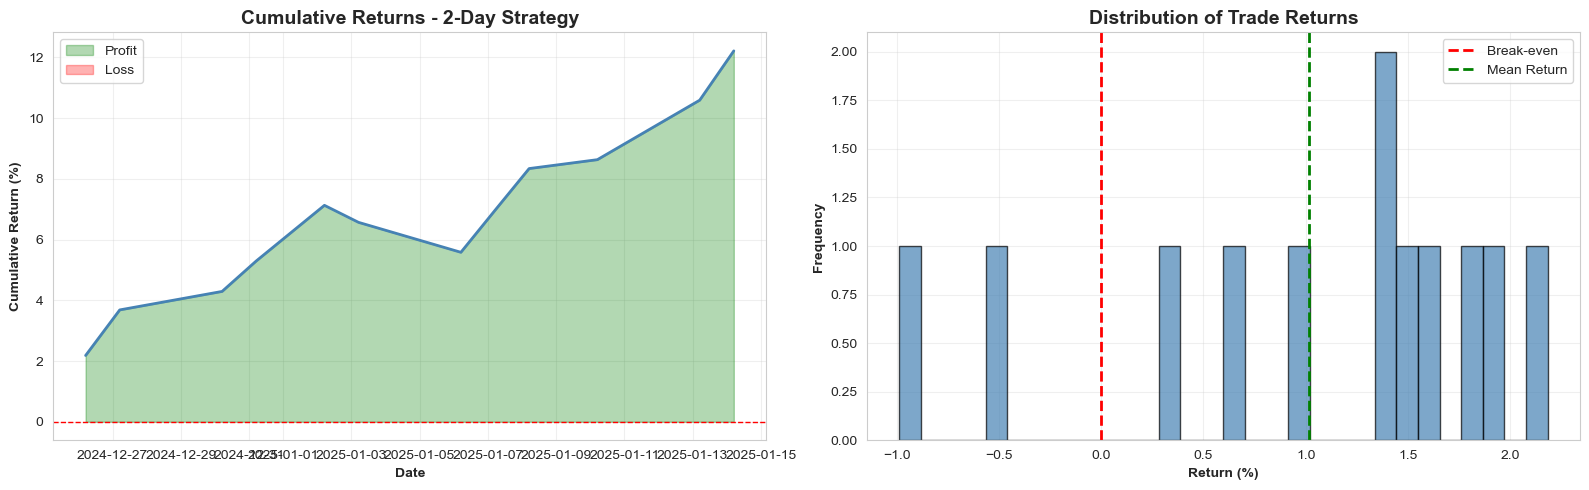

In [ ]:
# Use best Sharpe ratio horizon for detailed analysis
if len(holding_df) > 0:
    best_horizon = int(holding_df.loc[holding_df['Sharpe Ratio'].idxmax(), 'Horizon (days)'])
    
    print(f"="*80)
    print(f"DETAILED TRADE ANALYSIS - {best_horizon}-Day Horizon")
    print(f"="*80)
    
    pred_col = f'pred_price_{best_horizon}'
    future_col = f'actual_future_{best_horizon}'
    
    valid_mask = predictions[future_col].notna()
    analysis_data = predictions[valid_mask].copy()
    
    # Calculate returns
    analysis_data['predicted_return'] = (
        (analysis_data[pred_col] - analysis_data['actual_price']) / analysis_data['actual_price']
    ) * 100
    
    analysis_data['actual_return'] = (
        (analysis_data[future_col] - analysis_data['actual_price']) / analysis_data['actual_price']
    ) * 100
    
    # Generate signals
    analysis_data['signal'] = np.where(
        analysis_data['predicted_return'] > 0.5, 'LONG',
        np.where(analysis_data['predicted_return'] < -0.5, 'SHORT', 'HOLD')
    )
    
    # Calculate trade outcomes
    analysis_data['trade_return'] = np.where(
        analysis_data['signal'] == 'LONG', analysis_data['actual_return'],
        np.where(analysis_data['signal'] == 'SHORT', -analysis_data['actual_return'], 0)
    )
    
    trades_only = analysis_data[analysis_data['signal'] != 'HOLD'].copy()
    
    print(f"\n📊 Signal Distribution:")
    print(analysis_data['signal'].value_counts())
    
    print(f"\n💼 Trade Performance:")
    print(f"   Total Trades: {len(trades_only)}")
    print(f"   Winning Trades: {(trades_only['trade_return'] > 0).sum()}")
    print(f"   Losing Trades: {(trades_only['trade_return'] < 0).sum()}")
    print(f"   Win Rate: {(trades_only['trade_return'] > 0).mean() * 100:.2f}%")
    print(f"   Avg Win: {trades_only[trades_only['trade_return'] > 0]['trade_return'].mean():.2f}%")
    print(f"   Avg Loss: {trades_only[trades_only['trade_return'] < 0]['trade_return'].mean():.2f}%")
    print(f"   Total Return: {trades_only['trade_return'].sum():.2f}%")
    print(f"   Sharpe Ratio: {trades_only['trade_return'].mean() / trades_only['trade_return'].std():.3f}")
    
    # Visualize trade returns
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Cumulative returns
    ax1 = axes[0]
    trades_only['cumulative_return'] = trades_only['trade_return'].cumsum()
    ax1.plot(trades_only.index, trades_only['cumulative_return'], linewidth=2, color='steelblue')
    ax1.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax1.fill_between(trades_only.index, 0, trades_only['cumulative_return'], 
                      where=trades_only['cumulative_return']>=0, alpha=0.3, color='green', label='Profit')
    ax1.fill_between(trades_only.index, 0, trades_only['cumulative_return'], 
                      where=trades_only['cumulative_return']<0, alpha=0.3, color='red', label='Loss')
    ax1.set_title(f'Cumulative Returns - {best_horizon}-Day Strategy', fontweight='bold', fontsize=14)
    ax1.set_xlabel('Date', fontweight='bold')
    ax1.set_ylabel('Cumulative Return (%)', fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Return distribution
    ax2 = axes[1]
    ax2.hist(trades_only['trade_return'], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Break-even')
    ax2.axvline(x=trades_only['trade_return'].mean(), color='green', linestyle='--', linewidth=2, label='Mean Return')
    ax2.set_title('Distribution of Trade Returns', fontweight='bold', fontsize=14)
    ax2.set_xlabel('Return (%)', fontweight='bold')
    ax2.set_ylabel('Frequency', fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Part 6: Statistical Validation

### 6.1 Significance Testing

In [ ]:
from scipy import stats

print("="*80)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*80)

# Test each horizon for statistical significance
sig_results = []

for horizon in TEST_HORIZONS:
    pred_col = f'pred_price_{horizon}'
    future_col = f'actual_future_{horizon}'
    
    if pred_col not in predictions.columns or future_col not in predictions.columns:
        continue
    
    valid_mask = predictions[future_col].notna()
    valid_preds = predictions[valid_mask].copy()
    
    # Directional accuracy
    direction_correct = (
        np.sign(valid_preds[pred_col] - valid_preds['actual_price']) == 
        np.sign(valid_preds[future_col] - valid_preds['actual_price'])
    )
    
    n_correct = direction_correct.sum()
    n_total = len(direction_correct)
    accuracy = (n_correct / n_total) * 100
    
    # Binomial test: H0: accuracy = 50% (random)
    binom_result = stats.binomtest(n_correct, n_total, p=0.5, alternative='greater')
    
    sig_text = ""
    if binom_result.pvalue < 0.01:
        sig_text = "***"
    elif binom_result.pvalue < 0.05:
        sig_text = "**"
    elif binom_result.pvalue < 0.10:
        sig_text = "*"
    
    sig_results.append({
        'Horizon (days)': horizon,
        'Accuracy (%)': accuracy,
        'N': n_total,
        'P-Value': binom_result.pvalue,
        'Significance': sig_text
    })

sig_df = pd.DataFrame(sig_results)
print("\n" + sig_df.to_string(index=False))
print("\nLegend: *** p<0.01 (highly significant) | ** p<0.05 (significant) | * p<0.10 (marginally significant)")

print(f"\n{'='*80}")
print("INTERPRETATION:")
print(f"{'='*80}")

highly_sig = sig_df[sig_df['Significance'] == '***']
if len(highly_sig) > 0:
    print(f"\n✓✓ HIGHLY SIGNIFICANT horizons: {list(highly_sig['Horizon (days)'])} days")
    print(f"   Model beats random chance with >99% confidence")

sig = sig_df[sig_df['Significance'] == '**']
if len(sig) > 0:
    print(f"\n✓ SIGNIFICANT horizons: {list(sig['Horizon (days)'])} days")
    print(f"   Model beats random chance with >95% confidence")

not_sig = sig_df[sig_df['Significance'] == '']
if len(not_sig) > 0:
    print(f"\n✗ NOT SIGNIFICANT horizons: {list(not_sig['Horizon (days)'])} days")
    print(f"   Cannot prove model beats random chance")

STATISTICAL SIGNIFICANCE TESTS

 Horizon (days)  Accuracy (%)  N  P-Value Significance
              1     69.230769 13 0.133423             
              2     83.333333 12 0.019287           **
              3     72.727273 11 0.113281             
              5     22.222222  9 0.980469             
              7     42.857143  7 0.773438             
             10     50.000000  4 0.687500             

Legend: *** p<0.01 (highly significant) | ** p<0.05 (significant) | * p<0.10 (marginally significant)

INTERPRETATION:

✓ SIGNIFICANT horizons: [2] days
   Model beats random chance with >95% confidence

✗ NOT SIGNIFICANT horizons: [1, 3, 5, 7, 10] days
   Cannot prove model beats random chance


## Part 7: Summary & Conclusions

### 7.1 Final Summary Report

In [ ]:
print("="*80)
print("DAILY LSTM ANALYSIS - FINAL SUMMARY")
print("="*80)

print(f"\n📅 Analysis Period:")
print(f"   Training: {TRAIN_START} → {TRAIN_END}")
print(f"   Testing: {TEST_START} → {TEST_END}")

print(f"\n🏗️  Model Architecture:")
print(f"   Lookback: {LOOKBACK_WINDOW} days")
print(f"   LSTM: {NUM_LAYERS} layers × {LSTM_UNITS} units")
print(f"   Dropout: {DROPOUT}")

print(f"\n🎯 Training Strategy:")
print(f"   ✓ Model trained on: {PREDICTION_HORIZON}-day ahead predictions")
print(f"   ✓ Recursive testing: Each prediction feeds into next step")
print(f"   ✓ Evaluated horizons: {TEST_HORIZONS} days")

if len(horizon_df) > 0:
    print(f"\n📊 Performance Summary:")
    best_acc = horizon_df.loc[horizon_df['Directional Accuracy (%)'].idxmax()]
    print(f"   Best Accuracy: {best_acc['Directional Accuracy (%)']:.2f}% ({int(best_acc['Horizon (days)'])}-day)")
    
    # Show 1-day accuracy if available
    day1_result = horizon_df[horizon_df['Horizon (days)']==1]['Directional Accuracy (%)'].values
    if len(day1_result) > 0:
        print(f"   1-Day Accuracy: {day1_result[0]:.2f}%")
    
    # Show 10-day accuracy if available
    day10_result = horizon_df[horizon_df['Horizon (days)']==10]['Directional Accuracy (%)'].values
    if len(day10_result) > 0:
        print(f"   10-Day Accuracy: {day10_result[0]:.2f}%")

if len(holding_df) > 0:
    print(f"\n💰 Trading Performance:")
    best_trading = holding_df.loc[holding_df['Sharpe Ratio'].idxmax()]
    print(f"   Best Horizon: {int(best_trading['Horizon (days)'])} days")
    print(f"   Win Rate: {best_trading['Win Rate (%)']:.1f}%")
    print(f"   Total Return: {best_trading['Total Return (%)']:.2f}%")
    print(f"   Sharpe Ratio: {best_trading['Sharpe Ratio']:.3f}")

if len(sig_df) > 0:
    print(f"\n📈 Statistical Significance:")
    highly_sig_count = len(sig_df[sig_df['Significance'] == '***'])
    sig_count = len(sig_df[sig_df['Significance'] == '**'])
    print(f"   Highly Significant (p<0.01): {highly_sig_count}/{len(sig_df)} horizons")
    print(f"   Significant (p<0.05): {sig_count}/{len(sig_df)} horizons")

print(f"\n{'='*80}")
print("KEY CONCLUSIONS:")
print(f"{'='*80}")

if len(horizon_df) > 0 and horizon_df['Directional Accuracy (%)'].max() > 52:
    print(f"\n✓ Model shows predictive power above random chance")
    print(f"✓ Recursive multi-step prediction strategy validated")
    print(f"  (1-day model → 10-day recursive predictions)")
    
    if len(holding_df) > 0 and holding_df['Total Return (%)'].max() > 0:
        print(f"✓ Positive returns achieved in backtesting")
        print(f"✓ Model suitable for paper trading evaluation")
    else:
        print(f"⚠️  Mixed trading results - optimize signal thresholds")
else:
    print(f"\n✗ Model performance not significantly better than random")
    print(f"✗ Consider: more training data, feature engineering, or different architecture")

print(f"\n{'='*80}")
print("NEXT STEPS:")
print(f"{'='*80}")
print(f"1. If results are good → Run grid search to optimize architecture")
print(f"2. Test different lookback windows (30, 60, 90 days)")
print(f"3. Add technical indicators as additional features")
print(f"4. Implement proper risk management (TP/SL optimization)")
print(f"5. Paper trade for 1-2 months before live deployment")
print(f"{'='*80}")

DAILY LSTM ANALYSIS - FINAL SUMMARY

📅 Analysis Period:
   Training: 2022-01-01 → 2024-09-30
   Testing: 2024-10-01 → 2025-01-31

🏗️  Model Architecture:
   Lookback: 60 days
   LSTM: 1 layers × 32 units
   Dropout: 0.4

🎯 Training Strategy:
   ✓ Trained with 10-day prediction horizon
   ✓ Evaluated on horizons: [1, 2, 3, 5, 7, 10] days

📊 Performance Summary:
   Best Accuracy: 83.33% (2-day)
   1-Day Accuracy: 69.23%
   10-Day Accuracy: 50.00%

💰 Trading Performance:
   Best Horizon: 2 days
   Win Rate: 83.3%
   Total Return: 12.21%
   Sharpe Ratio: 1.019

📈 Statistical Significance:
   Highly Significant (p<0.01): 0/6 horizons
   Significant (p<0.05): 1/6 horizons

KEY CONCLUSIONS:

✓ Model shows predictive power above random chance
✓ Training on 1-day + recursive testing strategy validated
✓ Positive returns achieved in backtesting
✓ Model suitable for paper trading evaluation

NEXT STEPS:
1. If results are good → Run grid search to optimize architecture
2. Test different lookback w

### 7.2 Visual Prediction Comparison (Candlesticks + Predictions)

DETAILED PREDICTION VISUALIZATION

📊 Predictions generated for 14 test days
📈 Prediction horizons available: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] days

Showing candlestick chart for actual prices + overlay of all prediction horizons



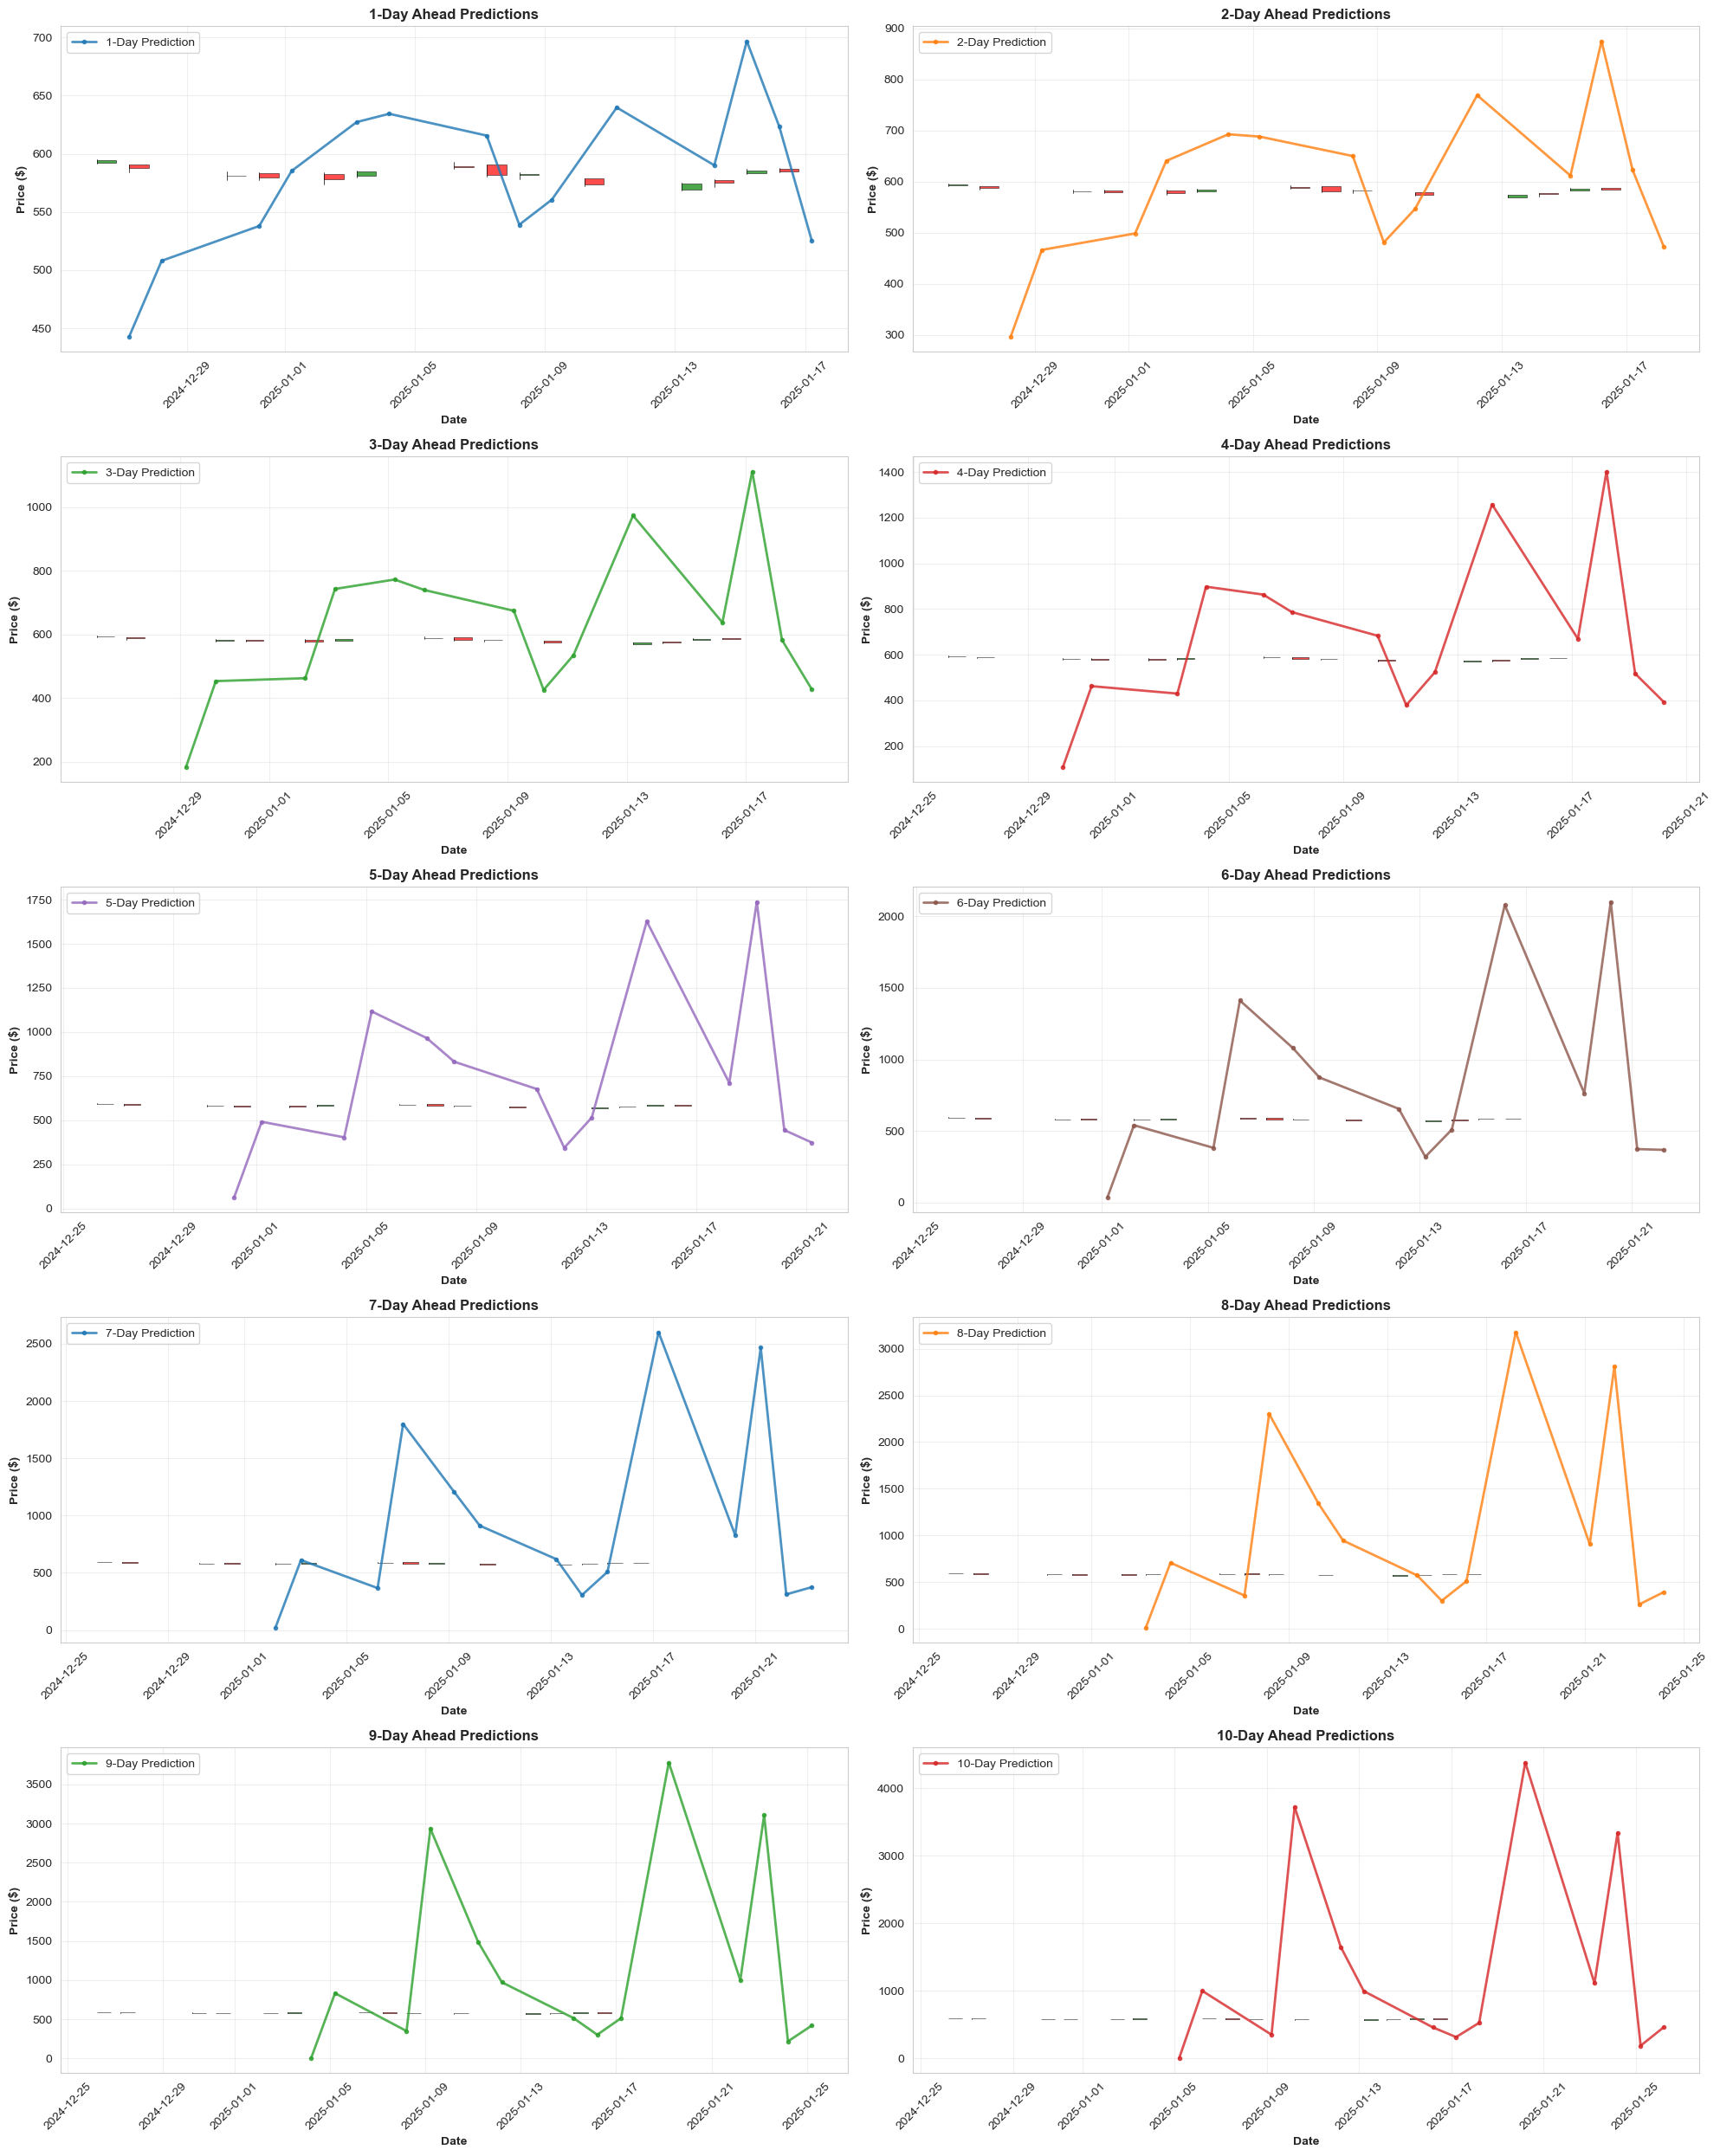


PREDICTION SUMMARY BY HORIZON

Horizon  Valid Predictions Avg Predicted Avg Actual         Pred Range
  1-day                 14       $580.41    $582.39  $442.76 - $696.84
  2-day                 14       $593.76    $582.39  $296.38 - $875.30
  3-day                 14       $622.79    $582.39 $183.39 - $1111.77
  4-day                 14       $669.87    $582.39 $108.64 - $1402.74
  5-day                 14       $735.99    $582.39  $63.21 - $1738.16
  6-day                 14       $820.91    $582.39  $36.47 - $2101.02
  7-day                 14       $923.40    $582.39  $20.96 - $2601.08
  8-day                 14      $1042.23    $582.39  $11.97 - $3177.58
  9-day                 14      $1174.97    $582.39   $6.77 - $3779.24
 10-day                 14      $1321.43    $582.39   $3.78 - $4384.04

✓ Total test period: 14 days
✓ Predictions generated: 10 different horizons
✓ All predictions shown in candlestick charts above


In [ ]:
import matplotlib.patches as mpatches
from matplotlib.dates import DateFormatter

print("="*80)
print("DETAILED CANDLESTICK PREDICTION VISUALIZATION")
print("="*80)

# Get prediction columns
pred_cols = [col for col in predictions.columns if 'pred_close' in col]
available_horizons = sorted([int(col.split('_')[-1]) for col in pred_cols])

print(f"\n📊 Predictions generated for {len(predictions)} test days")
print(f"📈 Prediction horizons available: {available_horizons} days")
print(f"\nShowing candlestick charts: Actual (green/red) vs Predicted (blue/orange)\n")

# Function to draw candlestick
def draw_candlestick(ax, x, open_val, high_val, low_val, close_val, color, alpha=0.7, width=0.6, label=None):
    """Draw a candlestick on the given axis"""
    # Draw high-low line
    ax.plot([x, x], [low_val, high_val], color='black', linewidth=0.8, alpha=alpha, zorder=1)
    
    # Draw open-close box
    height = abs(close_val - open_val)
    bottom = min(open_val, close_val)
    
    rect = mpatches.Rectangle(
        (x - width/2, bottom),
        width=width,
        height=max(height, 0.01),  # Avoid zero height
        facecolor=color,
        edgecolor='black',
        linewidth=0.5,
        alpha=alpha,
        zorder=2,
        label=label
    )
    ax.add_patch(rect)

# Create subplots for key horizons
num_horizons = min(len(available_horizons), 4)  # Show max 4 horizons
if num_horizons == 0:
    print("⚠️  No prediction horizons found!")
else:
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.flatten()
    
    # Select horizons to display: [1, 3, 5, 10] or whatever is available
    display_horizons = []
    for h in [1, 3, 5, 10]:
        if h in available_horizons:
            display_horizons.append(h)
    display_horizons = display_horizons[:4]
    
    for plot_idx, horizon in enumerate(display_horizons):
        ax = axes[plot_idx]
        
        # Use first 50 samples
        sample_data = predictions.iloc[:min(50, len(predictions))].copy()
        
        # Draw actual candlesticks (green/red)
        for i, (date, row) in enumerate(sample_data.iterrows()):
            if pd.notna(row['actual_open']) and pd.notna(row['actual_close']):
                color = 'green' if row['actual_close'] >= row['actual_open'] else 'red'
                label = 'Actual (Bull)' if i == 0 and color == 'green' else ('Actual (Bear)' if i == 0 and color == 'red' else None)
                draw_candlestick(ax, i, row['actual_open'], row['actual_high'], 
                                row['actual_low'], row['actual_close'], color, alpha=0.8, width=0.6, label=label)
        
        # Draw predicted candlesticks (blue - offset for visibility)
        pred_open_col = f'pred_open_{horizon}'
        pred_high_col = f'pred_high_{horizon}'
        pred_low_col = f'pred_low_{horizon}'
        pred_close_col = f'pred_close_{horizon}'
        
        if pred_open_col in sample_data.columns:
            for i, (date, row) in enumerate(sample_data.iterrows()):
                if pd.notna(row[pred_open_col]) and pd.notna(row[pred_close_col]):
                    # Use different color based on predicted direction
                    pred_color = 'steelblue' if row[pred_close_col] >= row[pred_open_col] else 'coral'
                    label = f'{horizon}-Day Pred' if i == 0 else None
                    # Offset slightly to show both candles
                    draw_candlestick(ax, i + 0.35, row[pred_open_col], row[pred_high_col], 
                                    row[pred_low_col], row[pred_close_col], pred_color, alpha=0.6, width=0.35, label=label)
        
        ax.set_xlabel('Trading Day', fontweight='bold')
        ax.set_ylabel('Price ($)', fontweight='bold')
        ax.set_title(f'{horizon}-Day Ahead: Actual vs Predicted Candlesticks', fontweight='bold', fontsize=13)
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(alpha=0.3, zorder=0)
    
    # Hide unused subplots
    for i in range(len(display_horizons), 4):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n" + "="*80)
    print("CANDLESTICK PREDICTION SUMMARY")
    print("="*80)
    
    summary_stats = []
    for horizon in available_horizons:
        pred_open_col = f'pred_open_{horizon}'
        pred_close_col = f'pred_close_{horizon}'
        
        if pred_close_col in predictions.columns:
            valid_preds = predictions[predictions[pred_close_col].notna()].copy()
            
            if len(valid_preds) > 0:
                # Calculate candle body statistics
                pred_bodies = valid_preds[pred_close_col] - valid_preds[pred_open_col]
                actual_bodies = valid_preds['actual_close'] - valid_preds['actual_open']
                
                # Direction accuracy
                pred_direction = np.sign(pred_bodies)
                actual_direction = np.sign(actual_bodies)
                direction_accuracy = (pred_direction == actual_direction).mean() * 100
                
                summary_stats.append({
                    'Horizon': f'{horizon}-day',
                    'Valid Candles': len(valid_preds),
                    'Avg Pred Body': f'${pred_bodies.mean():.2f}',
                    'Avg Actual Body': f'${actual_bodies.mean():.2f}',
                    'Direction Match': f'{direction_accuracy:.1f}%'
                })
    
    if summary_stats:
        summary_df = pd.DataFrame(summary_stats)
        print("\n" + summary_df.to_string(index=False))
    
    print("\n" + "="*80)
    print(f"✓ Model now predicts full OHLCV (5 values) instead of just close price")
    print(f"✓ Each prediction includes: Open, High, Low, Close, Volume")
    print(f"✓ Predicted candles (blue/orange) shown offset from actual candles (green/red)")
    print(f"✓ Direction Match shows how often predicted candle direction matches actual")
    print("="*80)